# CBSA Graph Histograms by Year

Loads all `*_connected.json` graphs from `cbsas/{year}/` for years 1980–2020 and plots histograms of:
- **Number of nodes** per CBSA
- **Number of edges** per CBSA
- **Total population** per CBSA (sum of `TOTPOP` across all tracts)
- **Degree distribution** (all node degrees flattened across all CBSAs)

Set `SAMPLE_SIZE` to `None` to load every file (~2300/year); default is 500 for speed.

In [242]:
import json
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

YEARS                  = [1980, 1990, 2000, 2010, 2020]
CBSA_DIR               = '../study_areas'
CENSUS_GEOGRAPHY_TYPE  = 'tracts'   # 'tracts' or 'block_groups'
SAMPLE_SIZE            = 500        # set to None to load all files per year
VINTAGE                = 'march_2020'

In [243]:
import pandas as pd

_cbsa_df = pd.read_csv('cbsa-name dictionary.csv')
cbsa_dict = dict(zip(_cbsa_df['CBSA Code'], _cbsa_df['CBSA Name']))

In [244]:
import re as _re

def load_year(year, vintage=None, sample_size=None, cbsa_names=None):
    """Return list of per-CBSA summary dicts for a given census year."""
    pattern = os.path.join(CBSA_DIR, str(year), f'{CENSUS_GEOGRAPHY_TYPE}_in_cbsa_*_{year}_*_vintage_connected.json')
    files = sorted(glob.glob(pattern))
    if vintage is not None:
        files = [f for f in files if vintage in os.path.basename(f)]
    if sample_size is not None:
        files = files[:sample_size]

    records = []
    for fp in files:
        try:
            with open(fp) as f:
                d = json.load(f)
            nodes = d['nodes']
            adj   = d['adjacency']
            n_nodes   = len(nodes)
            n_edges   = sum(len(a) for a in adj) // 2
            degrees   = [len(a) for a in adj]
            n_leaves  = sum(1 for deg in degrees if deg == 1)
            max_deg   = max(degrees) if degrees else 0
            sum_totpop = sum((n.get('TOTPOP') or 0) for n in nodes)
            sum_poc    = sum((n.get('POC')    or 0) for n in nodes)
            sum_black  = sum((n.get('BLACK')  or 0) for n in nodes)
            sum_white  = sum((n.get('WHITE')  or 0) for n in nodes)
            poc_share   = sum_poc   / sum_totpop               if sum_totpop > 0               else np.nan
            black_share = sum_black / (sum_black + sum_white)  if (sum_black + sum_white) > 0  else np.nan
            fname = os.path.basename(fp)
            m = _re.search(r'_in_cbsa_(\d+)_', fname)
            code  = int(m.group(1)) if m else None
            name  = cbsa_names.get(code, '') if cbsa_names and code is not None else ''
            records.append({
                'file':        fname,
                'cbsa_code':   code,
                'cbsa_name':   name,
                'n_nodes':     n_nodes,
                'n_edges':     n_edges,
                'n_leaves':    n_leaves,
                'max_deg':     max_deg,
                'total_pop':   sum_totpop,
                'poc_share':   poc_share,
                'black_share': black_share,
                'degrees':     degrees,
            })
        except Exception as e:
            print(f'  skipped {os.path.basename(fp)}: {e}')
            continue
    return records


data = {}
for yr in [1980, 1990, 2000, 2010, 2020]:
    print(f'Loading {yr}...', end=' ', flush=True)
    records = load_year(yr, vintage=VINTAGE, sample_size=SAMPLE_SIZE, cbsa_names=cbsa_dict)
    if records:
        data[yr] = records
        print(f'{len(records)} graphs')
    else:
        print('no files found, skipping')

# YEARS is the set of years that actually have data — adapts to tracts vs block_groups
YEARS = sorted(data.keys())
print(f'Active years: {YEARS}')

Loading 1980... 335 graphs
Loading 1990... 384 graphs
Loading 2000... 392 graphs
Loading 2010... 392 graphs
Loading 2020... 392 graphs
Active years: [1980, 1990, 2000, 2010, 2020]


In [245]:
# ── Tukey upper-fence thresholds (pooled across all loaded decades) ───────────
def tukey_upper(vals):
    if not vals:
        return 0.0
    q1, q3 = np.percentile(vals, [25, 75])
    return q3 + 1.5 * (q3 - q1)

thresh_nodes  = tukey_upper([r['n_nodes']   for yr in data for r in data[yr]])
thresh_edges  = tukey_upper([r['n_edges']   for yr in data for r in data[yr]])
thresh_pop    = tukey_upper([r['total_pop'] for yr in data for r in data[yr]])
thresh_deg    = tukey_upper([d              for yr in data for r in data[yr] for d in r['degrees']])
thresh_leaves = tukey_upper([r['n_leaves']  for yr in data for r in data[yr]])

lines = [
    f"Tukey upper-fence thresholds (pooled across {YEARS}, vintage={VINTAGE}):",
    f"  Nodes:      {thresh_nodes:>12,.0f}",
    f"  Edges:      {thresh_edges:>12,.0f}",
    f"  Population: {thresh_pop:>12,.0f}",
    f"  Degree:     {thresh_deg:>12.1f}",
    f"  Leaves:     {thresh_leaves:>12,.0f}",
]
for line in lines:
    print(line)

os.makedirs('figures', exist_ok=True)
with open('figures/thresholds.txt', 'w') as f:
    f.write('\n'.join(lines) + '\n')
print('Saved figures/thresholds.txt')

Tukey upper-fence thresholds (pooled across [1980, 1990, 2000, 2010, 2020], vintage=march_2020):
  Nodes:               239
  Edges:               632
  Population:    1,033,649
  Degree:              9.0
  Leaves:                2
Saved figures/thresholds.txt


Saved figures/cbsa_top10_nodes_edges.png


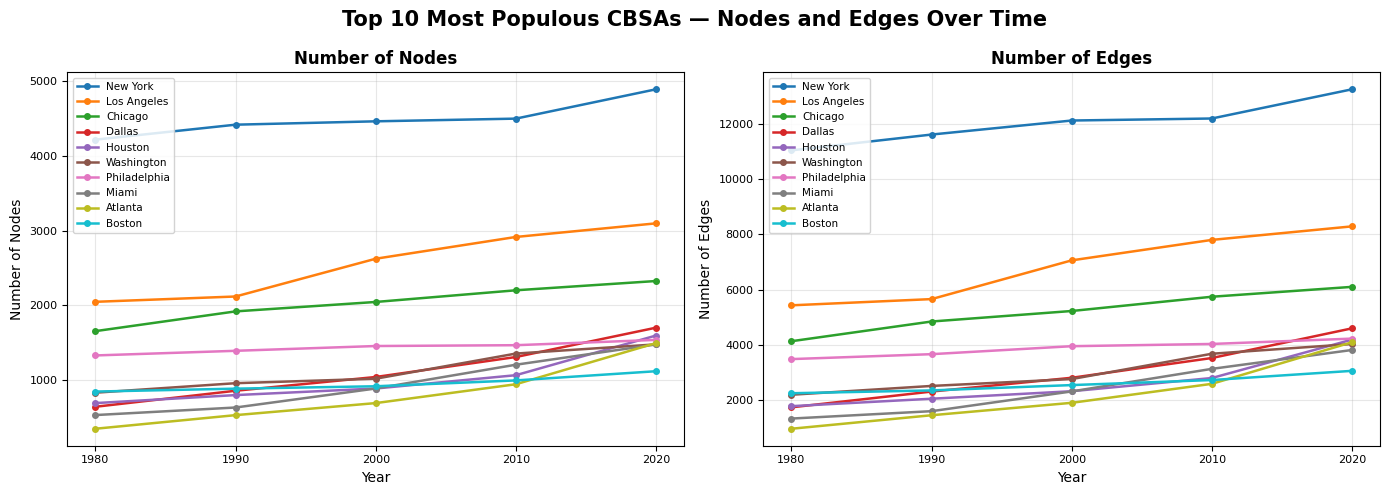

Saved figures/cbsa_density.png


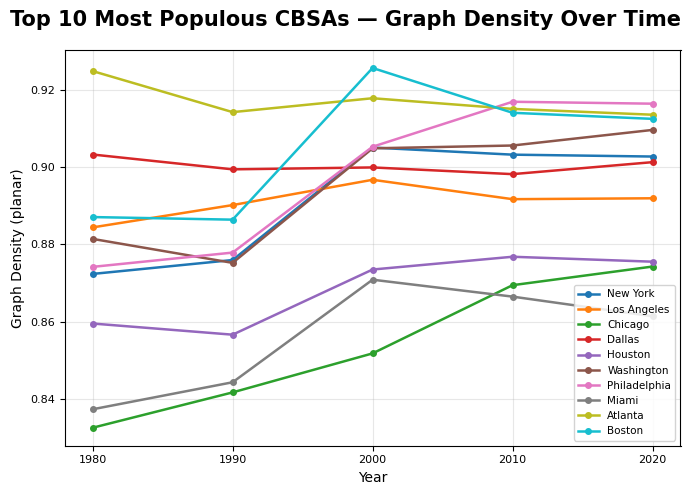

Saved figures/cbsa_max_degree_leaves.png


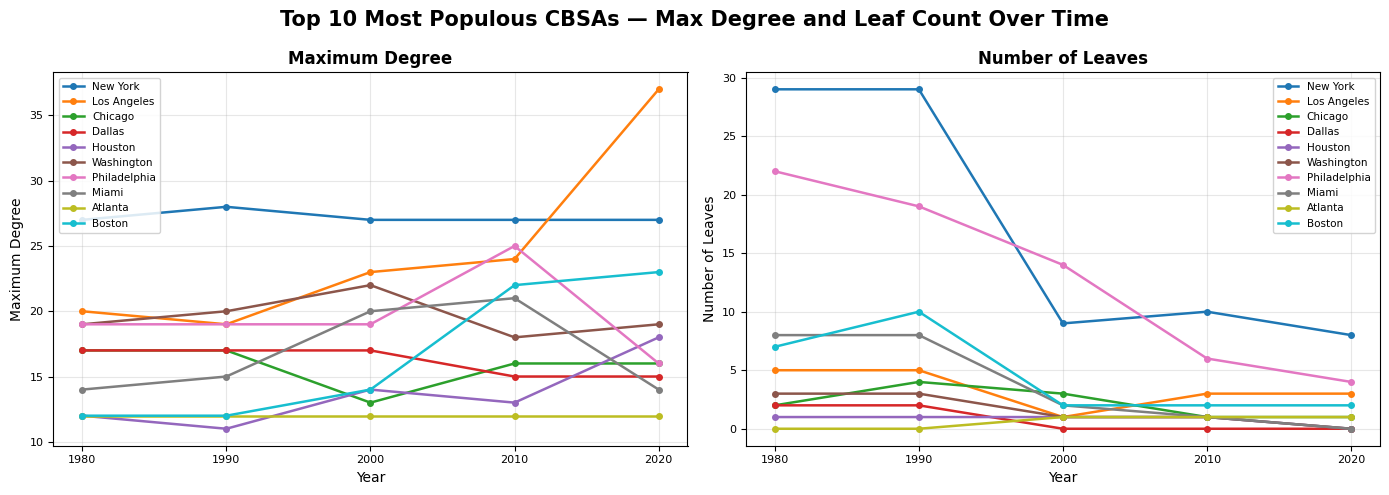

In [246]:
os.makedirs('figures', exist_ok=True)

def _short(name):
    if not name:
        return '?'
    return name.split(',')[0].split('-')[0].strip()[:18]

def _density(r):
    n = r['n_nodes']
    return r['n_edges'] / (3 * n - 6) if n >= 3 else 0.0

TOP_N = 10

# Build {cbsa_code: {year: record}} lookup
cbsa_by_year = {}
for yr in YEARS:
    for r in data[yr]:
        cbsa_by_year.setdefault(r['cbsa_code'], {})[yr] = r

# Top 10 most populous CBSAs (by 2020 total population)
top10_codes = [r['cbsa_code'] for r in sorted(data[2020], key=lambda r: r['total_pop'], reverse=True)[:TOP_N]]


def _top10_spag(ax, codes, metric_fn, ylabel, title=None):
    """Spaghetti plot for a fixed list of CBSA codes."""
    for code in codes:
        city = cbsa_by_year.get(code, {})
        pts  = [(yr, metric_fn(city[yr])) for yr in YEARS if yr in city]
        pts  = [(yr, v) for yr, v in pts
                if v is not None and not (isinstance(v, float) and np.isnan(v))]
        if len(pts) >= 2:
            yrs, vals = zip(*pts)
            name = city.get(2020, city.get(max(city)))['cbsa_name']
            ax.plot(yrs, vals, marker='o', markersize=4, linewidth=1.8, label=_short(name))
    ax.set_xticks(YEARS)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xlabel('Year', fontsize=10)
    ax.tick_params(labelsize=8)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7.5, loc='best', framealpha=0.85)
    if title:
        ax.set_title(title, fontsize=12, fontweight='bold')


# ── Figure 1: nodes and edges ─────────────────────────────────────────────────
fig1, (ax1a, ax1b) = plt.subplots(1, 2, figsize=(14, 5))
fig1.suptitle('Top 10 Most Populous CBSAs — Nodes and Edges Over Time', fontsize=15, fontweight='bold')
_top10_spag(ax1a, top10_codes, lambda r: r['n_nodes'], 'Number of Nodes', 'Number of Nodes')
_top10_spag(ax1b, top10_codes, lambda r: r['n_edges'], 'Number of Edges', 'Number of Edges')
plt.tight_layout()
fig1.savefig('figures/cbsa_top10_nodes_edges.png', dpi=150, bbox_inches='tight')
print('Saved figures/cbsa_top10_nodes_edges.png')
plt.show()

# ── Figure 2: density ─────────────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(7, 5))
fig2.suptitle('Top 10 Most Populous CBSAs — Graph Density Over Time', fontsize=15, fontweight='bold')
_top10_spag(ax2, top10_codes, _density, 'Graph Density (planar)')
plt.tight_layout()
fig2.savefig('figures/cbsa_density.png', dpi=150, bbox_inches='tight')
print('Saved figures/cbsa_density.png')
plt.show()

# ── Figure 3: max degree and leaves ──────────────────────────────────────────
fig3, (ax3a, ax3b) = plt.subplots(1, 2, figsize=(14, 5))
fig3.suptitle('Top 10 Most Populous CBSAs — Max Degree and Leaf Count Over Time', fontsize=15, fontweight='bold')
_top10_spag(ax3a, top10_codes, lambda r: r['max_deg'],  'Maximum Degree',   'Maximum Degree')
_top10_spag(ax3b, top10_codes, lambda r: r['n_leaves'], 'Number of Leaves', 'Number of Leaves')
plt.tight_layout()
fig3.savefig('figures/cbsa_max_degree_leaves.png', dpi=150, bbox_inches='tight')
print('Saved figures/cbsa_max_degree_leaves.png')
plt.show()

Saved figures/cbsa_degree_distributions.png


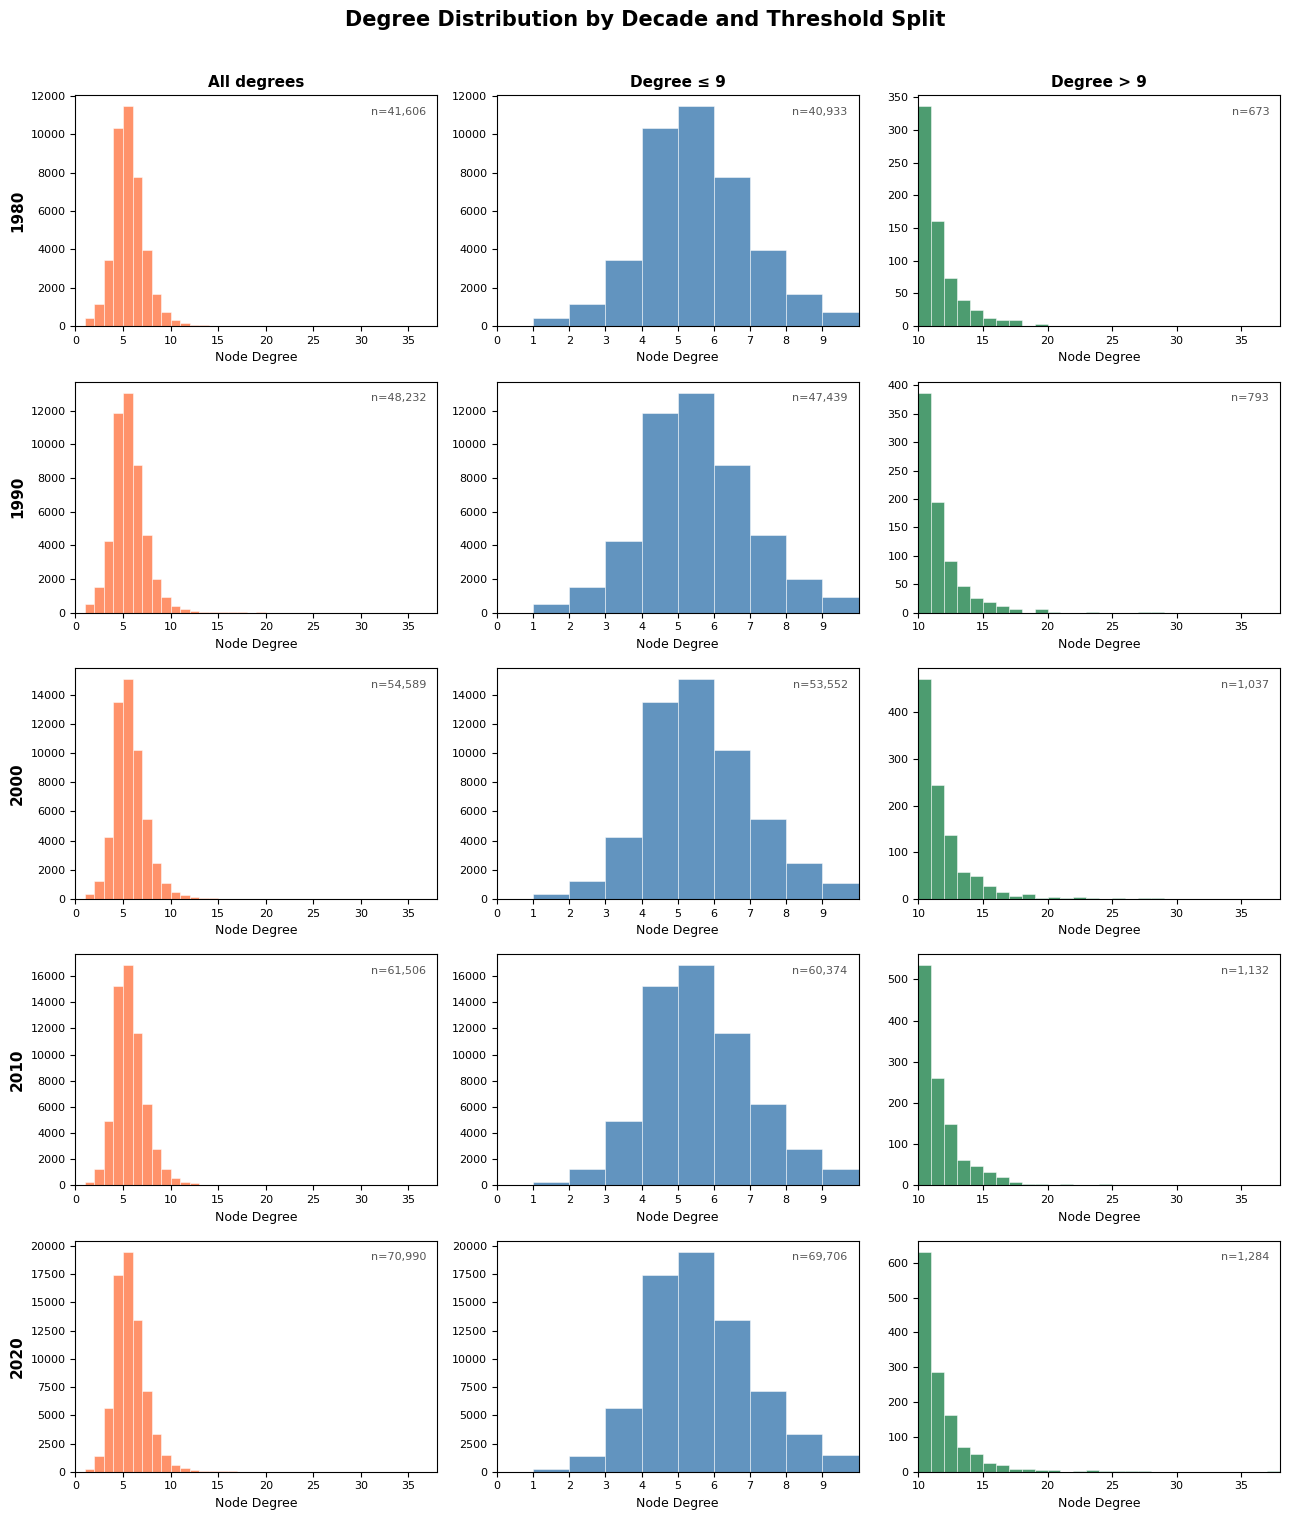

In [247]:
# ── Degree distribution: 5 rows (decades) × 3 cols (all / ≤9 / >9) ──────────
all_degrees_flat = [d for yr in YEARS for r in data[yr] for d in r['degrees']]
max_deg_all = max(all_degrees_flat) if all_degrees_flat else 1
THRESH = int(thresh_deg)  # 9

COLORS = ['coral', 'steelblue', 'seagreen']

fig, axes = plt.subplots(len(YEARS), 3, figsize=(13, 3 * len(YEARS)))
fig.suptitle('Degree Distribution by Decade and Threshold Split',
             fontsize=15, fontweight='bold', y=1.01)

for row, yr in enumerate(YEARS):
    all_deg_yr = [d for r in data[yr] for d in r['degrees']]
    for col in range(3):
        ax = axes[row][col]

        if col == 0:
            vals  = all_deg_yr
            bins  = list(range(0, max_deg_all + 2))
            xlim  = (0, max_deg_all + 1)
            label = 'All degrees'
            xticks = None
        elif col == 1:
            vals   = [d for d in all_deg_yr if d <= THRESH]
            bins   = list(range(0, THRESH + 2))      # [0 … 10]
            xlim   = (0, THRESH + 1)
            label  = f'Degree ≤ {THRESH}'
            xticks = list(range(0, THRESH + 1))      # ticks 0 … 9 only
        else:
            vals   = [d for d in all_deg_yr if d > THRESH]
            bins   = list(range(THRESH + 1, max_deg_all + 2))
            xlim   = (THRESH + 1, max_deg_all + 1)
            label  = f'Degree > {THRESH}'
            xticks = None

        if vals:
            ax.hist(vals, bins=bins, color=COLORS[col],
                    edgecolor='white', linewidth=0.4, alpha=0.85)

        ax.set_xlim(*xlim)
        if xticks is not None:
            ax.set_xticks(xticks)
        if row == 0:
            ax.set_title(label, fontsize=11, fontweight='bold')
        if col == 0:
            ax.set_ylabel(str(yr), fontsize=11, fontweight='bold')
        ax.set_xlabel('Node Degree', fontsize=9)
        ax.tick_params(labelsize=8)
        ax.text(0.97, 0.95, f'n={len(vals):,}', transform=ax.transAxes,
                ha='right', va='top', fontsize=8, color='#555')

plt.tight_layout()
fig.savefig('figures/cbsa_degree_distributions.png', dpi=150, bbox_inches='tight')
print('Saved figures/cbsa_degree_distributions.png')
plt.show()


1980: New York-Newark-Jersey City, NY-NJ-PA  max_deg=27


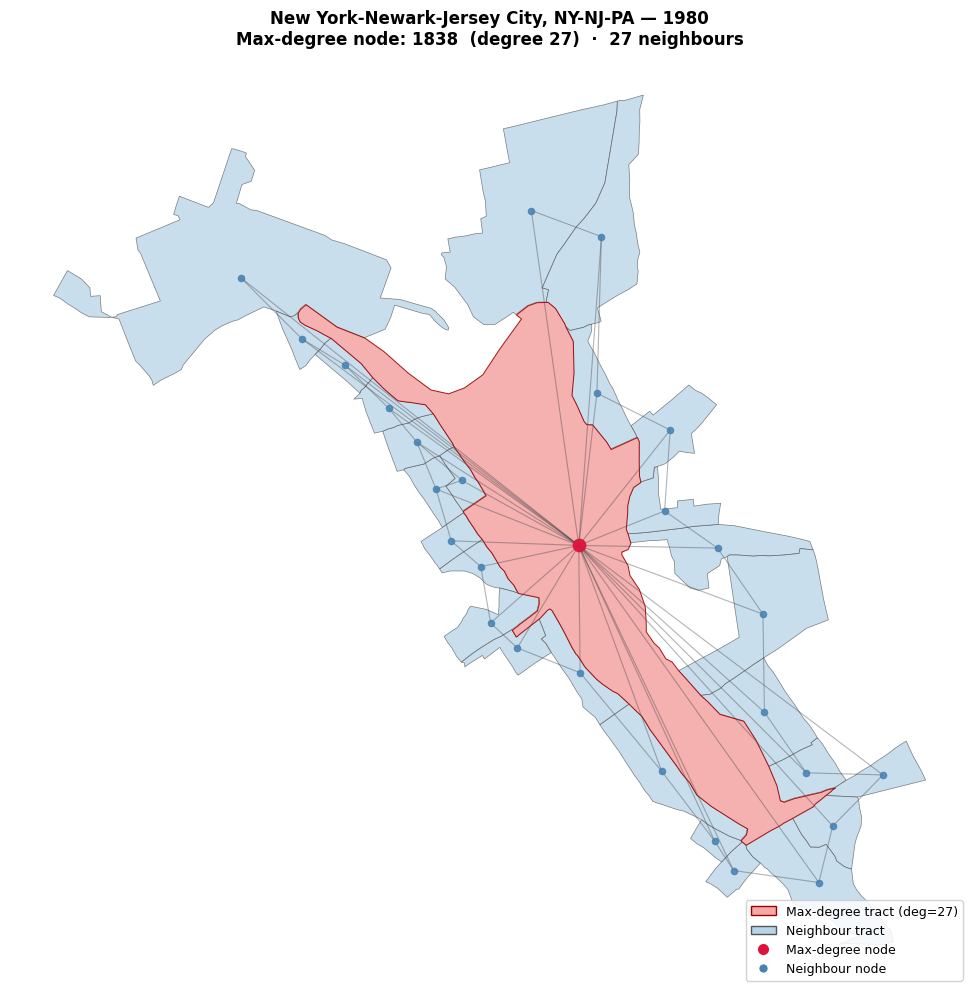

  Saved 1 tracts → /Users/samstephenson/Desktop/Degree Outliers/New York_1980_degree_outlier.shp

1990: New York-Newark-Jersey City, NY-NJ-PA  max_deg=28


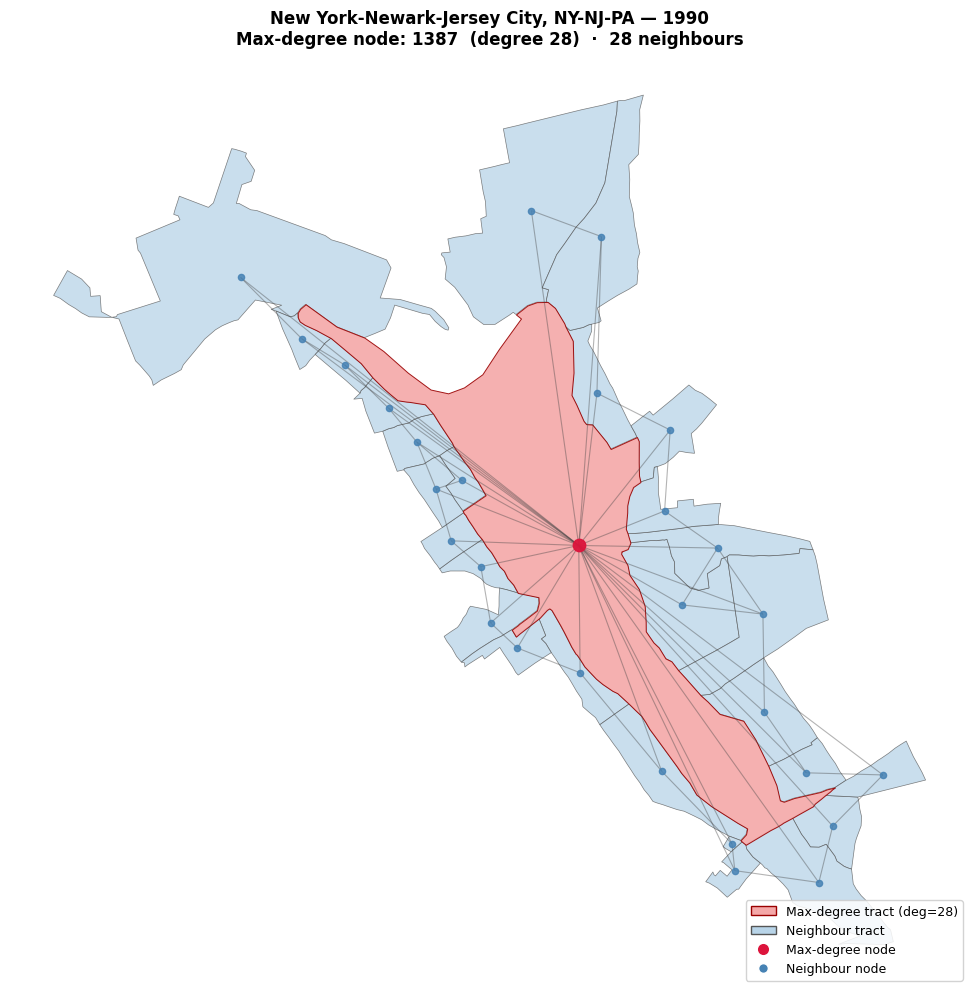

  Saved 1 tracts → /Users/samstephenson/Desktop/Degree Outliers/New York_1990_degree_outlier.shp

2000: San Francisco-Oakland-Hayward, CA  max_deg=28


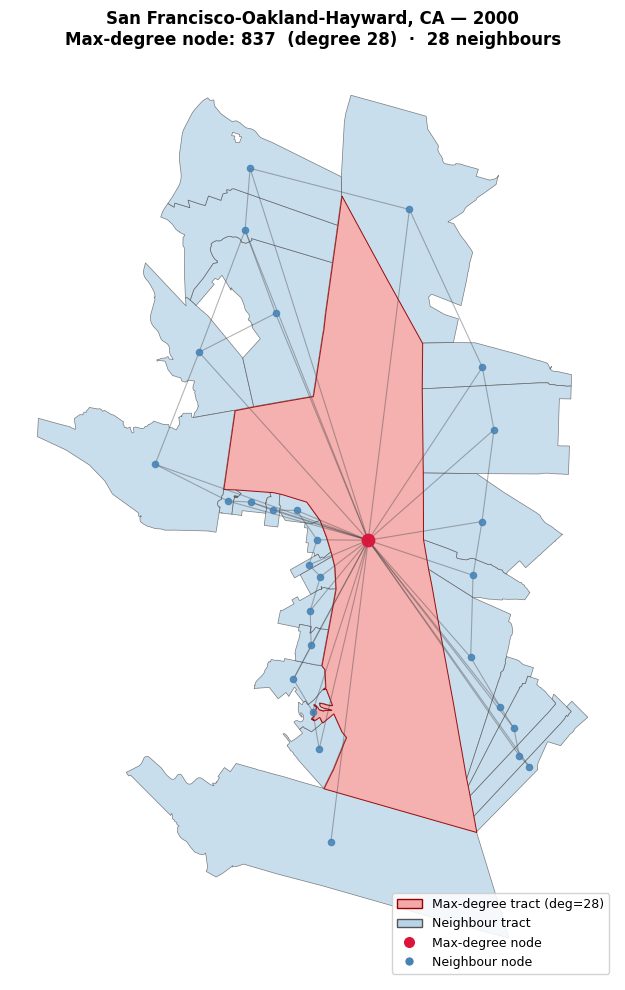

  Saved 1 tracts → /Users/samstephenson/Desktop/Degree Outliers/San Francisco_2000_degree_outlier.shp

2010: New York-Newark-Jersey City, NY-NJ-PA  max_deg=27


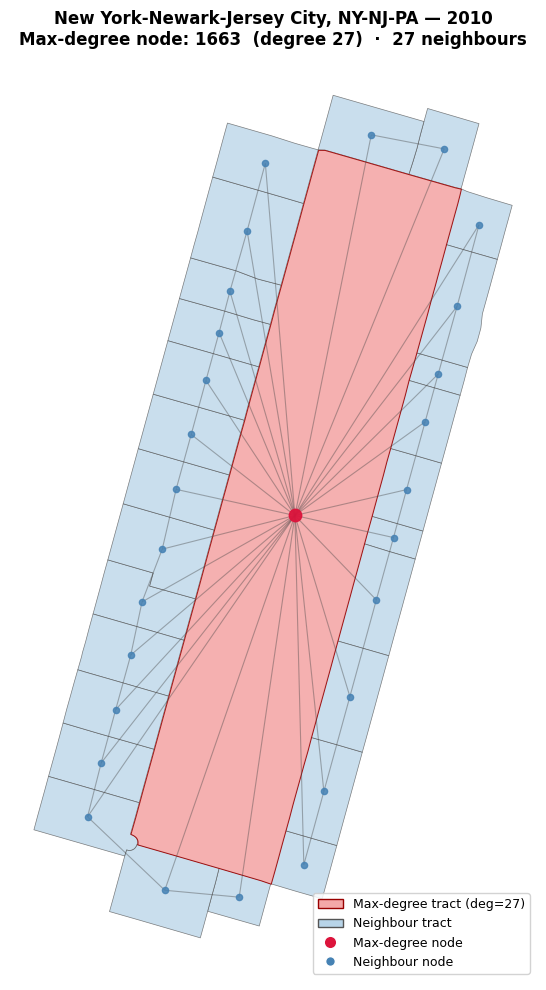

  Saved 1 tracts → /Users/samstephenson/Desktop/Degree Outliers/New York_2010_degree_outlier.shp

2020: Los Angeles-Long Beach-Anaheim, CA  max_deg=37


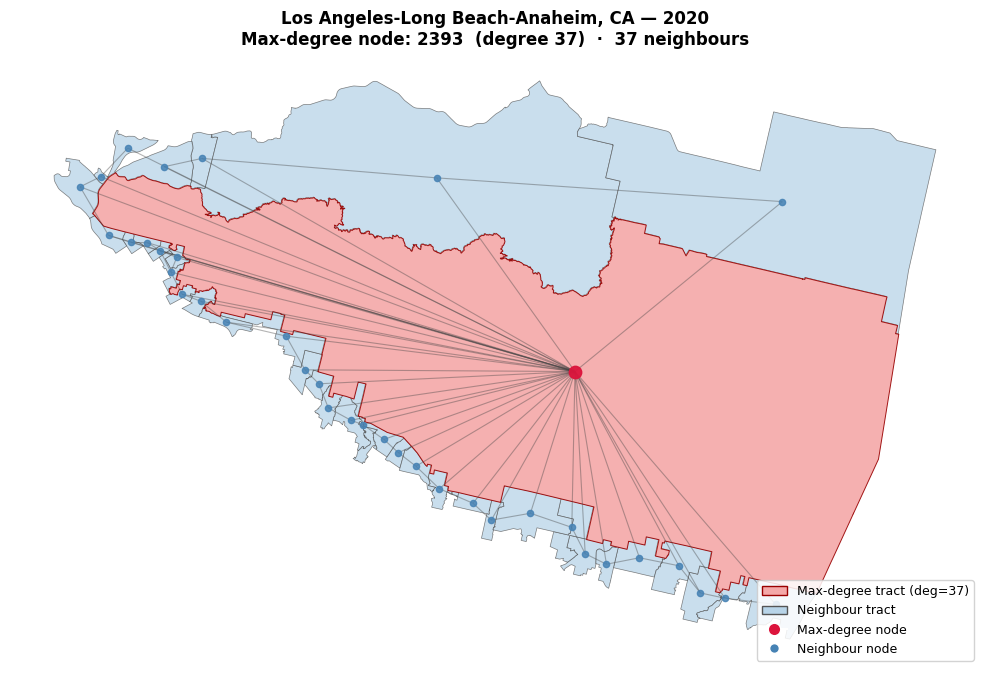

  Saved 1 tracts → /Users/samstephenson/Desktop/Degree Outliers/Los Angeles_2020_degree_outlier.shp


In [248]:
import networkx as nx
import geopandas as gpd
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

OUT_DIR = '/Users/samstephenson/Desktop/Degree Outliers'


def load_full_graph(fp):
    with open(fp) as f:
        d = json.load(f)
    nodes_list = d['nodes']
    G = nx.Graph()
    for node in nodes_list:
        G.add_node(node['id'], **node)
    for i, neighbours in enumerate(d['adjacency']):
        src_id = nodes_list[i]['id']
        for nb in neighbours:
            j = nb['id']
            if src_id < j:
                G.add_edge(src_id, j)
    return G


def plot_and_save_degree_outlier(record, yr, out_dir):
    fp       = os.path.join(CBSA_DIR, str(yr), record['file'])
    cbsa_name = record['cbsa_name'] or str(record['cbsa_code'])
    city_name = cbsa_name.split(',')[0].split('-')[0].strip()

    G = load_full_graph(fp)

    max_node      = max(G.nodes(), key=lambda n: G.degree(n))
    max_deg_val   = G.degree(max_node)
    neighbor_nodes = set(G.neighbors(max_node))
    target_nodes   = {max_node} | neighbor_nodes

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.set_title(
        f'{cbsa_name} — {yr}\n'
        f'Max-degree node: {max_node}  (degree {max_deg_val})  ·  {len(neighbor_nodes)} neighbours',
        fontsize=12, fontweight='bold',
    )

    # Shapefile overlay — connected files share the same .shp as orig files
    shp_path = fp.replace('_connected.json', '.shp')
    xlim = ylim = None
    if os.path.exists(shp_path):
        gdf = gpd.read_file(shp_path).to_crs('esri:102003')
        max_gisjoin = {G.nodes[max_node].get('GISJOIN')}
        nbr_gisjoin = {G.nodes[n].get('GISJOIN') for n in neighbor_nodes}

        gdf[gdf['GISJOIN'].isin(nbr_gisjoin)].plot(
            ax=ax, color='#b8d4e8', edgecolor='#555', linewidth=0.5, alpha=0.75)
        gdf[gdf['GISJOIN'].isin(max_gisjoin)].plot(
            ax=ax, color='#f4a8a8', edgecolor='#990000', linewidth=0.7, alpha=0.9)
        xlim, ylim = ax.get_xlim(), ax.get_ylim()
    else:
        print(f'  Shapefile not found: {shp_path}')

    # Graph overlay
    pos = {n: (G.nodes[n]['centroid_x'], G.nodes[n]['centroid_y'])
           for n in target_nodes
           if 'centroid_x' in G.nodes[n] and 'centroid_y' in G.nodes[n]}
    if pos:
        H = G.subgraph(list(pos.keys()))
        nx.draw_networkx_edges(H, pos, ax=ax, alpha=0.4, width=0.8, edge_color='#444')
        nbr_in_pos = [n for n in neighbor_nodes if n in pos]
        if nbr_in_pos:
            nx.draw_networkx_nodes(H, pos, nodelist=nbr_in_pos, ax=ax,
                                   node_color='steelblue', node_size=20, alpha=0.85)
        if max_node in pos:
            nx.draw_networkx_nodes(H, pos, nodelist=[max_node], ax=ax,
                                   node_color='crimson', node_size=80, alpha=0.95)
        if xlim:
            ax.set_xlim(xlim)
            ax.set_ylim(ylim)

    legend_elements = [
        Patch(facecolor='#f4a8a8', edgecolor='#990000', label=f'Max-degree tract (deg={max_deg_val})'),
        Patch(facecolor='#b8d4e8', edgecolor='#555',    label='Neighbour tract'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='crimson',
               markersize=9, label='Max-degree node'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue',
               markersize=7, label='Neighbour node'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=9, framealpha=0.85)
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

    # Save shapefile: max-degree node only
    if os.path.exists(shp_path):
        gdf = gpd.read_file(shp_path).to_crs('esri:102003')
        max_gisjoin = {G.nodes[max_node].get('GISJOIN')}
        out = gdf[gdf['GISJOIN'].isin(max_gisjoin)].copy()
        out['max_deg'] = max_deg_val
        os.makedirs(out_dir, exist_ok=True)
        out_path = os.path.join(out_dir, f'{city_name}_{yr}_degree_outlier.shp')
        out.to_file(out_path)
        print(f'  Saved {len(out)} tracts → {out_path}')


for yr in YEARS:
    top_rec = max(data[yr], key=lambda r: r['max_deg'])
    print(f'\n{yr}: {top_rec["cbsa_name"]}  max_deg={top_rec["max_deg"]}')
    plot_and_save_degree_outlier(top_rec, yr, OUT_DIR)

In [249]:
# ── Summary table ─────────────────────────────────────────────────────────────
print(f"{'Year':>6}  {'CBSAs':>6}  {'Med Nodes':>10}  {'Med Edges':>10}  {'Med TotPop':>12}  {'Med Degree':>11}")
print('-' * 64)
for yr in YEARS:
    recs = data[yr]
    nodes  = [r['n_nodes']   for r in recs]
    edges  = [r['n_edges']   for r in recs]
    pops   = [r['total_pop'] for r in recs]
    degs   = [d for r in recs for d in r['degrees']]
    print(f"{yr:>6}  {len(recs):>6}  "
          f"{np.median(nodes):>10.0f}  "
          f"{np.median(edges):>10.0f}  "
          f"{np.median(pops):>12,.0f}  "
          f"{np.median(degs):>11.2f}")

  Year   CBSAs   Med Nodes   Med Edges    Med TotPop   Med Degree
----------------------------------------------------------------
  1980     335          45         112       177,712         5.00
  1990     384          45         110       182,054         5.00
  2000     392          49         116       201,520         5.00
  2010     392          52         130       230,476         5.00
  2020     392          63         160       243,728         5.00


## Split Histograms

Figures 2 and 3 mirror the full layout above but split on a **Tukey upper-fence threshold** computed from pooled data across all decades:

```
threshold = Q3 + 1.5 × IQR   (where Q1/Q3 are pooled over 1980–2020)
```

Thresholds are printed by the cell above. The split is clean: Figure 2 uses `< threshold` (strictly below) and Figure 3 uses `>= threshold` (at or above), so each observation appears in exactly one figure.

In [250]:
# ── Top-20 outliers per year per metric ───────────────────────────────────────
OUTLIER_METRICS = [
    ('n_nodes',   'Nodes',      lambda r: r['n_nodes'],                 '{:>6}'),
    ('n_edges',   'Edges',      lambda r: r['n_edges'],                 '{:>6}'),
    ('total_pop', 'Total Pop',  lambda r: r['total_pop'],               '{:>12,}'),
    ('max_deg',   'Max Degree', lambda r: max(r['degrees'], default=0), '{:>10}'),
    ('n_leaves',  'Leaves',     lambda r: r['n_leaves'],                '{:>6}'),
]

TOP_N = 20

for metric_key, metric_label, key_fn, val_fmt in OUTLIER_METRICS:
    print(f"\n{'='*80}")
    print(f"  Top {TOP_N} by {metric_label}")
    print(f"{'='*80}")
    for yr in YEARS:
        ranked = sorted(data[yr], key=key_fn, reverse=True)[:TOP_N]
        print(f"\n  {yr}")
        print(f"  {'Rank':>4}  {'Code':>6}  {metric_label:>12}  Name")
        print(f"  {'-'*70}")
        for i, r in enumerate(ranked, 1):
            val_str = val_fmt.format(key_fn(r))
            print(f"  {i:>4}  {str(r['cbsa_code']):>6}  {val_str}  {r['cbsa_name']}")


  Top 20 by Nodes

  1980
  Rank    Code         Nodes  Name
  ----------------------------------------------------------------------
     1   35620    4217  New York-Newark-Jersey City, NY-NJ-PA
     2   31080    2049  Los Angeles-Long Beach-Anaheim, CA
     3   16980    1657  Chicago-Naperville-Elgin, IL-IN-WI
     4   37980    1332  Philadelphia-Camden-Wilmington, PA-NJ-DE-MD
     5   19820    1109  Detroit-Warren-Dearborn, MI
     6   14460     849  Boston-Cambridge-Newton, MA-NH
     7   47900     834  Washington-Arlington-Alexandria, DC-VA-MD-WV
     8   41860     787  San Francisco-Oakland-Hayward, CA
     9   38300     718  Pittsburgh, PA
    10   26420     695  Houston-The Woodlands-Sugar Land, TX
    11   19100     646  Dallas-Fort Worth-Arlington, TX
    12   33460     609  Minneapolis-St. Paul-Bloomington, MN-WI
    13   12580     564  Baltimore-Columbia-Towson, MD
    14   17460     564  Cleveland-Elyria, OH
    15   33100     535  Miami-Fort Lauderdale-West Palm Beach, F

In [251]:
# ── Top-20 rank-difference pairs ──────────────────────────────────────────────
# For each pair of metrics, rank all CBSAs in a given year (rank 1 = largest),
# then find the 20 with the biggest absolute difference between the two ranks.

RANK_PAIRS = [
    ('pop',   'nodes', lambda r: r['total_pop'], lambda r: r['n_nodes']),
    ('pop',   'edges', lambda r: r['total_pop'], lambda r: r['n_edges']),
    ('nodes', 'edges', lambda r: r['n_nodes'],   lambda r: r['n_edges']),
]

for label_a, label_b, key_a, key_b in RANK_PAIRS:
    print(f"\n{'='*85}")
    print(f"  Top {TOP_N} absolute rank differences: {label_a} vs {label_b}")
    print(f"{'='*85}")
    for yr in YEARS:
        recs = data[yr]
        rank_a = {r['file']: i + 1 for i, r in enumerate(sorted(recs, key=key_a, reverse=True))}
        rank_b = {r['file']: i + 1 for i, r in enumerate(sorted(recs, key=key_b, reverse=True))}

        scored = sorted(recs,
                        key=lambda r: abs(rank_a[r['file']] - rank_b[r['file']]),
                        reverse=True)[:TOP_N]

        print(f"\n  {yr}  (n={len(recs)} CBSAs)")
        print(f"  {'#':>3}  {'Code':>6}  {'Rk('+label_a+')':>10}  {'Rk('+label_b+')':>10}  {'|Diff|':>8}  Name")
        print(f"  {'-'*75}")
        for i, r in enumerate(scored, 1):
            ra   = rank_a[r['file']]
            rb   = rank_b[r['file']]
            diff = abs(ra - rb)
            print(f"  {i:>3}  {str(r['cbsa_code']):>6}  {ra:>10}  {rb:>10}  {diff:>8}  {r['cbsa_name']}")


  Top 20 absolute rank differences: pop vs nodes

  1980  (n=335 CBSAs)
    #    Code     Rk(pop)   Rk(nodes)    |Diff|  Name
  ---------------------------------------------------------------------------
    1   29180         196         288        92  Lafayette, LA
    2   22220         166         255        89  Fayetteville-Springdale-Rogers, AR-MO
    3   12620         212         147        65  Bangor, ME
    4   23540         193         257        64  Gainesville, FL
    5   39380         229         166        63  Pueblo, CO
    6   30620         249         190        59  Lima, OH
    7   20100         274         217        57  Dover, DE
    8   24020         254         197        57  Glens Falls, NY
    9   32900         216         273        57  Merced, CA
   10   32580         120         175        55  McAllen-Edinburg-Mission, TX
   11   13220         199         253        54  Beckley, WV
   12   46220         210         264        54  Tuscaloosa, AL
   13   41140  